# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves. Thanks [Yandex Data School Analysis](https://github.com/yandexdataschool/Practical_DL/blob/fall21/week03_convnets/seminar_pytorch.ipynb) for this work!

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

![image](https://github.com/yandexdataschool/Practical_DL/raw/fall21/week03_convnets/cifar10.jpg)

In [2]:
# when running in colab, un-comment this
!wget https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall19/week03_convnets/cifar.py

--2026-04-20 20:01:15--  https://raw.githubusercontent.com/yandexdataschool/Practical_DL/fall19/week03_convnets/cifar.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2396 (2.3K) [text/plain]
Saving to: ‘cifar.py.1’

cifar.py.1          100%[===================>]   2.34K  --.-KB/s    in 0s      

2026-04-20 20:01:15 (58.1 MB/s) - ‘cifar.py.1’ saved [2396/2396]



In [3]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer',
                        'dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

(40000, 3, 32, 32) (40000,)


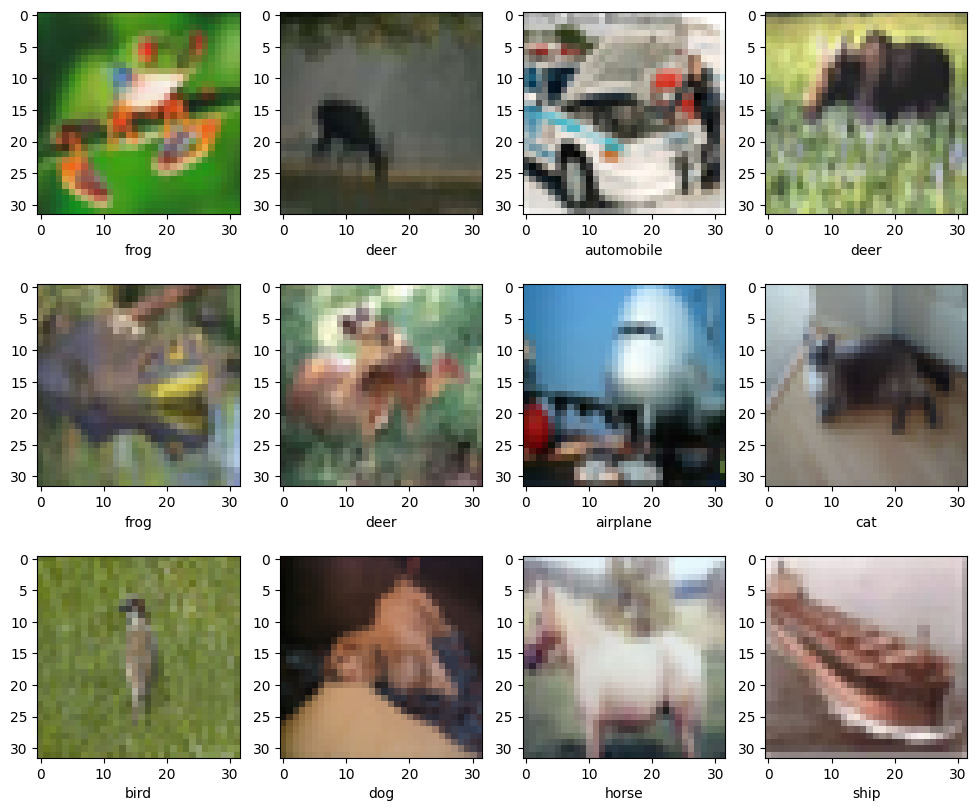

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

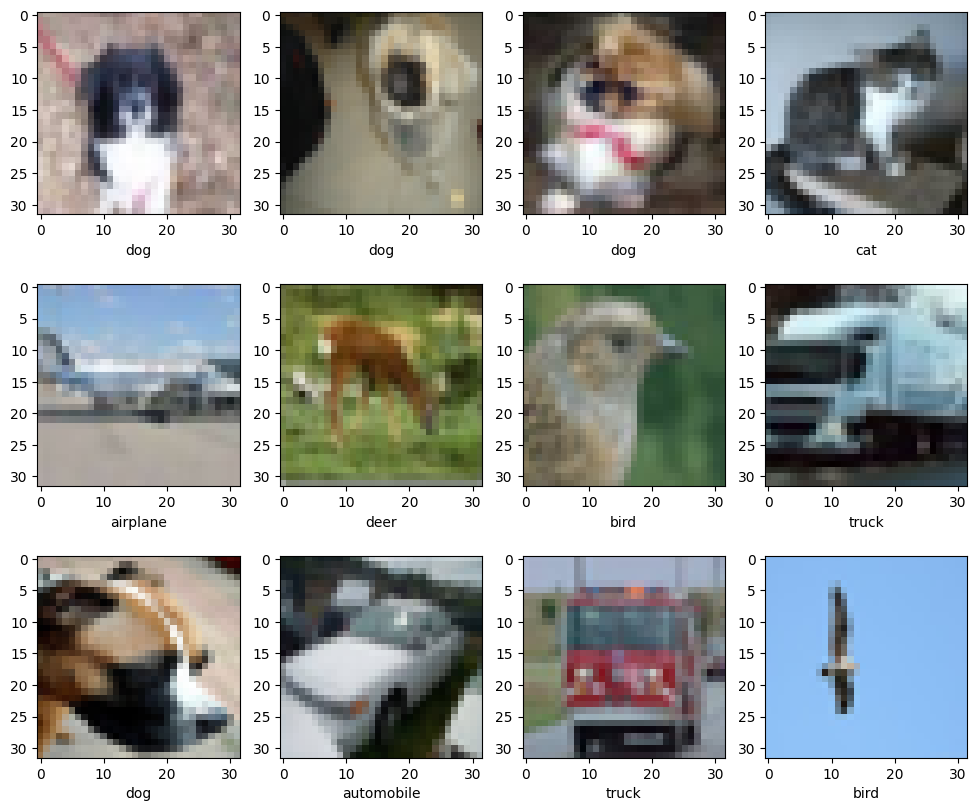

In [69]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_val[i]])
    plt.imshow(np.transpose(X_val[i],[1,2,0]))

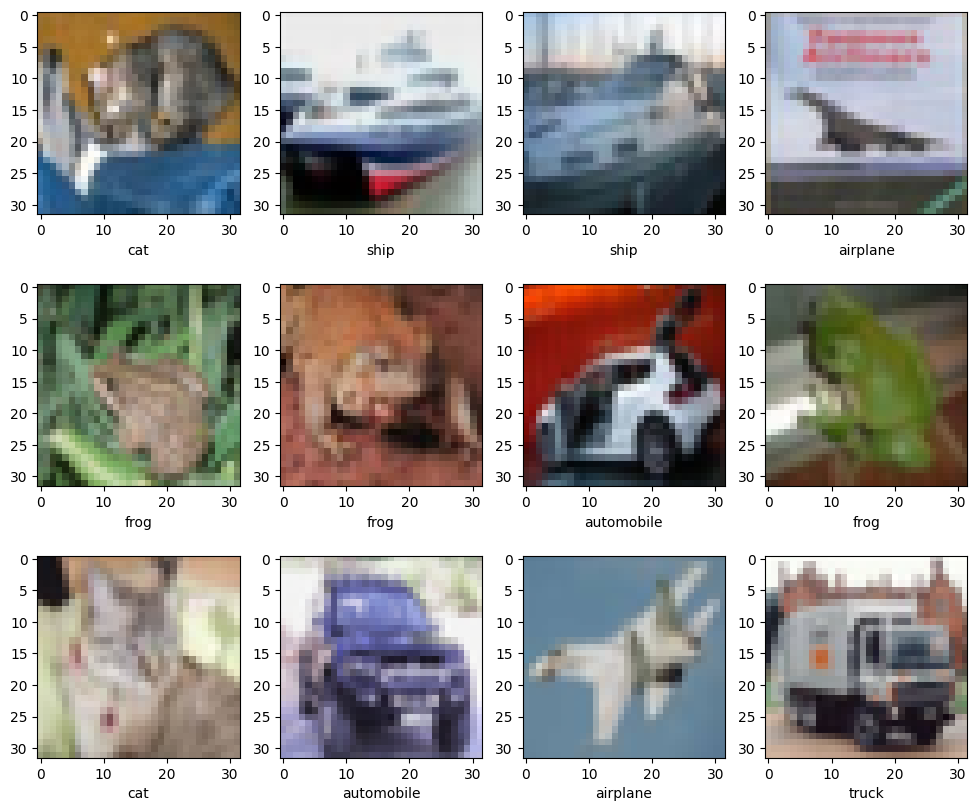

In [70]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_test[i]])
    plt.imshow(np.transpose(X_test[i],[1,2,0]))

<BarContainer object of 10 artists>

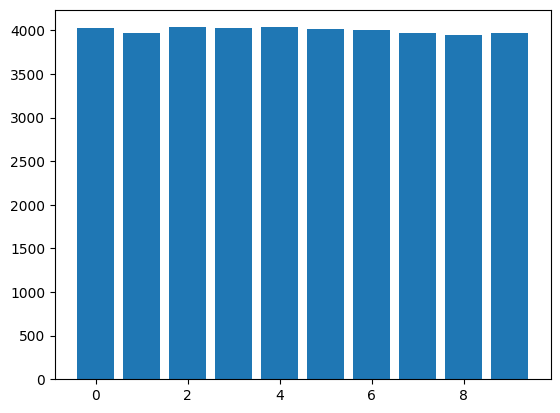

In [11]:
values, counts = np.unique(y_train, return_counts=True)
plt.bar(values, counts)

<BarContainer object of 10 artists>

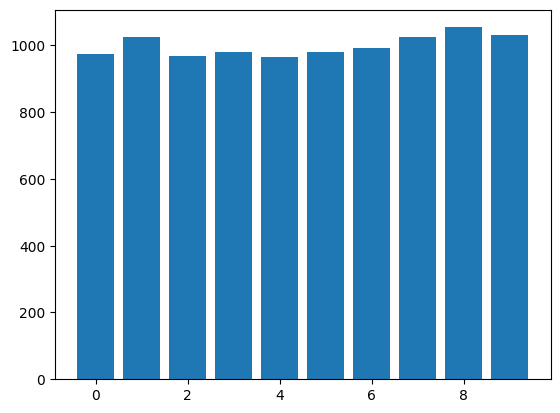

In [9]:
values, counts = np.unique(y_val, return_counts=True)
plt.bar(values, counts)

<BarContainer object of 10 artists>

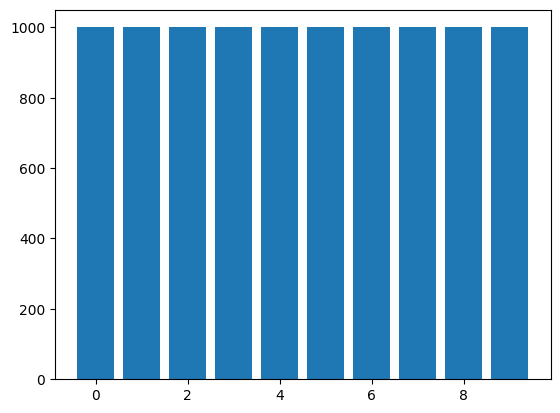

In [10]:
values, counts = np.unique(y_test, return_counts=True)
plt.bar(values, counts)

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

In [13]:
import torch, torch.nn as nn
import torch.nn.functional as F

# a special module that converts [batch, channel, w, h] to [batch, units]
class Flatten(nn.Module):
    def forward(self, input):
        return input.view(input.size(0), -1)

Let's start with a dense network for our baseline:

In [17]:
model = nn.Sequential()

# reshape from "images" to flat vectors
model.add_module('flatten', Flatten())

# dense "head"
model.add_module('dense1', nn.Linear(3 * 32 * 32, 64))
model.add_module('dense1_relu', nn.ReLU())
model.add_module('dense2_logits', nn.Linear(64, 10)) # logits for 10 classes

As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [14]:
def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32).to(device)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64).to(device)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [10]:
# example
device = torch.device("cuda")
model.to(device)
compute_loss(X_train[:5], y_train[:5])

tensor(2.3441, device='cuda:0', grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [15]:
# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

In [18]:
opt = torch.optim.Adam(model.parameters(), lr=0.001) # Changed optimizer to Adam with a default learning rate

train_loss = []
val_accuracy = []

In [13]:
import time
num_epochs = 20 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.cpu().data.numpy())

    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32).to(device))
        y_pred = logits.max(1)[1].cpu().data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))


    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 20 took 2.046s
  training loss (in-iteration): 	1.926898
  validation accuracy: 			35.55 %
Epoch 2 of 20 took 1.546s
  training loss (in-iteration): 	1.759117
  validation accuracy: 			39.32 %
Epoch 3 of 20 took 1.616s
  training loss (in-iteration): 	1.700233
  validation accuracy: 			39.72 %
Epoch 4 of 20 took 1.522s
  training loss (in-iteration): 	1.671012
  validation accuracy: 			41.39 %
Epoch 5 of 20 took 1.521s
  training loss (in-iteration): 	1.651240
  validation accuracy: 			41.43 %
Epoch 6 of 20 took 1.559s
  training loss (in-iteration): 	1.629670
  validation accuracy: 			42.00 %
Epoch 7 of 20 took 1.534s
  training loss (in-iteration): 	1.614507
  validation accuracy: 			42.53 %
Epoch 8 of 20 took 1.533s
  training loss (in-iteration): 	1.603165
  validation accuracy: 			42.54 %
Epoch 9 of 20 took 1.508s
  training loss (in-iteration): 	1.593579
  validation accuracy: 			41.76 %
Epoch 10 of 20 took 1.555s
  training loss (in-iteration): 	1.583455
  validation 

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [16]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32).to(device))
    y_pred = logits.max(1)[1].cpu().data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		42.42 %
We need more magic! Follow instructons below


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [17]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    Flatten(),
    nn.Linear(10 * 16 * 16, 100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
)

In [18]:
import time
num_epochs = 20 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

model.to(device)
model.train(True)
for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.cpu().data.numpy())

    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32).to(device))
        y_pred = logits.max(1)[1].cpu().data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))


    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 20 took 2.248s
  training loss (in-iteration): 	2.304843
  validation accuracy: 			13.37 %
Epoch 2 of 20 took 2.176s
  training loss (in-iteration): 	2.304982
  validation accuracy: 			13.37 %
Epoch 3 of 20 took 1.845s
  training loss (in-iteration): 	2.304606
  validation accuracy: 			13.37 %
Epoch 4 of 20 took 1.868s
  training loss (in-iteration): 	2.304780
  validation accuracy: 			13.37 %
Epoch 5 of 20 took 1.713s
  training loss (in-iteration): 	2.304880
  validation accuracy: 			13.37 %
Epoch 6 of 20 took 1.696s
  training loss (in-iteration): 	2.304735
  validation accuracy: 			13.37 %
Epoch 7 of 20 took 1.696s
  training loss (in-iteration): 	2.304774
  validation accuracy: 			13.37 %
Epoch 8 of 20 took 1.663s
  training loss (in-iteration): 	2.304724
  validation accuracy: 			13.37 %
Epoch 9 of 20 took 1.682s
  training loss (in-iteration): 	2.304567
  validation accuracy: 			13.37 %
Epoch 10 of 20 took 1.780s
  training loss (in-iteration): 	2.304682
  validation 

In [20]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32).to(device))
    y_pred = logits.max(1)[1].cpu().data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		12.93 %
We need more magic! Follow instructons below


```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [24]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, padding=1),
    nn.BatchNorm2d(10),
    nn.ReLU(),
    nn.MaxPool2d(2),
    Flatten(),
    nn.Linear(10 * 16 * 16, 100),
    nn.BatchNorm1d(100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
)

In [23]:
import time
num_epochs = 20 # total amount of full passes over training data
batch_size = 50  # number of samples processed in one SGD iteration

model.to(device)
model.train(True)
for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.cpu().data.numpy())

    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    for X_batch, y_batch in iterate_minibatches(X_val, y_val, batch_size):
        logits = model(torch.as_tensor(X_batch, dtype=torch.float32).to(device))
        y_pred = logits.max(1)[1].cpu().data.numpy()
        val_accuracy.append(np.mean(y_batch == y_pred))


    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss[-len(X_train) // batch_size :])))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy[-len(X_val) // batch_size :]) * 100))

Epoch 1 of 20 took 2.367s
  training loss (in-iteration): 	2.382178
  validation accuracy: 			10.10 %
Epoch 2 of 20 took 2.067s
  training loss (in-iteration): 	2.381851
  validation accuracy: 			9.93 %
Epoch 3 of 20 took 2.021s
  training loss (in-iteration): 	2.381511
  validation accuracy: 			10.09 %
Epoch 4 of 20 took 1.888s
  training loss (in-iteration): 	2.381330
  validation accuracy: 			9.91 %
Epoch 5 of 20 took 1.907s
  training loss (in-iteration): 	2.380770
  validation accuracy: 			10.01 %
Epoch 6 of 20 took 1.981s
  training loss (in-iteration): 	2.381957
  validation accuracy: 			10.08 %
Epoch 7 of 20 took 1.859s
  training loss (in-iteration): 	2.381440
  validation accuracy: 			9.93 %
Epoch 8 of 20 took 1.998s
  training loss (in-iteration): 	2.380365
  validation accuracy: 			10.00 %
Epoch 9 of 20 took 2.123s
  training loss (in-iteration): 	2.382626
  validation accuracy: 			9.99 %
Epoch 10 of 20 took 1.904s
  training loss (in-iteration): 	2.380297
  validation accu

In [24]:
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
for X_batch, y_batch in iterate_minibatches(X_test, y_test, 500):
    logits = model(torch.as_tensor(X_batch, dtype=torch.float32).to(device))
    y_pred = logits.max(1)[1].cpu().data.numpy()
    test_batch_acc.append(np.mean(y_batch == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		10.29 %
We need more magic! Follow instructons below



```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [19]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465))
stds = np.array((0.2023, 0.1994, 0.2010))

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [20]:
from torchvision.datasets import CIFAR10
train_loader = CIFAR10("./cifar_data/", train=True, transform=transform_augment)

train_batch_gen = torch.utils.data.DataLoader(train_loader,
                                              batch_size=128,
                                              shuffle=True,
                                              num_workers=1)

In [ ]:

for (x_batch, y_batch) in train_batch_gen:

    print('X:', type(x_batch), x_batch.shape)
    print('y:', type(y_batch), y_batch.shape)

    for i, img in enumerate(x_batch.numpy()[:8]):
        plt.subplot(2, 4, i+1)
        plt.imshow(img.transpose([1,2,0]) * stds + means )


    #raise NotImplementedError("Plese use this code in your training loop")
    # TODO use this in your training loop

When testing, we don't need random crops, just normalize with same statistics.

In [21]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

test_loader = CIFAR10("./cifar_data/", train=False, transform=transform_test)

test_batch_gen = torch.utils.data.DataLoader(test_loader,
                                              batch_size=128,
                                              shuffle=False,
                                              num_workers=1)

In [32]:
import time

opt = torch.optim.Adam(model.parameters(), lr=0.001) # Adam optimizer defined here

num_epochs = 20 # total amount of full passes over training data
batch_size = 128  # Use batch size from DataLoader

model.train(True)
for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    model.train(True) # enable dropout / batch_norm training behavior
    train_loss_epoch = []
    for X_batch, y_batch in train_batch_gen:
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss_epoch.append(loss.cpu().data.numpy())
    train_loss.extend(train_loss_epoch)

    # And a full pass over the validation data:
    model.train(False) # disable dropout / use averages for batch_norm
    val_accuracy_epoch = []
    for X_batch, y_batch in test_batch_gen:
        logits = model(X_batch.to(device))
        y_pred = logits.max(1)[1].cpu().data.numpy()
        val_accuracy_epoch.append(np.mean(y_batch.numpy() == y_pred))
    val_accuracy.extend(val_accuracy_epoch)


    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss_epoch)))
    print("  validation accuracy: \t\t\t{:.2f} %".format(
        np.mean(val_accuracy_epoch) * 100))

Epoch 1 of 20 took 31.179s
  training loss (in-iteration): 	1.477535
  validation accuracy: 			54.38 %
Epoch 2 of 20 took 30.239s
  training loss (in-iteration): 	1.421452
  validation accuracy: 			54.88 %
Epoch 3 of 20 took 31.574s
  training loss (in-iteration): 	1.388628
  validation accuracy: 			56.51 %
Epoch 4 of 20 took 30.063s
  training loss (in-iteration): 	1.368559
  validation accuracy: 			58.32 %
Epoch 5 of 20 took 30.214s
  training loss (in-iteration): 	1.337198
  validation accuracy: 			59.33 %
Epoch 6 of 20 took 30.244s
  training loss (in-iteration): 	1.323870
  validation accuracy: 			58.31 %
Epoch 7 of 20 took 29.447s
  training loss (in-iteration): 	1.314456
  validation accuracy: 			59.40 %
Epoch 8 of 20 took 29.522s
  training loss (in-iteration): 	1.300782
  validation accuracy: 			60.14 %
Epoch 9 of 20 took 33.130s
  training loss (in-iteration): 	1.289585
  validation accuracy: 			59.48 %
Epoch 10 of 20 took 29.955s
  training loss (in-iteration): 	1.285302
  v

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
   
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [ ]:
model = nn.Sequential(
    # Convolutional Block 1
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # 64 channels, 16x16 size
    nn.Dropout(0.25),

    # Convolutional Block 2
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # 128 channels, 8x8 size
    nn.Dropout(0.25),

    Flatten(), # 128 * 8 * 8 = 8192

    # Dense layers
    nn.Linear(128 * 8 * 8, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

for layer in model.children():
    if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
        if layer.bias is not None:
            nn.init.constant_(layer.bias, 0)


In [ ]:
import time
import copy

device = torch.device("cuda")
opt = torch.optim.Adam(model.parameters(), lr=0.001,
                       weight_decay=1e-4)

num_epochs = 100
batch_size = 32

early_stopping_patience = 10
best_val_accuracy = -1.0
epochs_no_improve = 0
best_model_state = None

train_loss = []
val_accuracy = []

model.to(device)
for epoch in range(num_epochs):
    # train
    start_time = time.time()
    model.train(True)
    train_loss_epoch = []
    for i, (X_batch, y_batch) in enumerate(train_batch_gen):
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss_epoch.append(loss.cpu().data.numpy())
    train_loss.extend(train_loss_epoch)

    # eval
    model.train(False)
    val_accuracy_epoch = []
    for X_batch, y_batch in test_batch_gen:
        logits = model(X_batch.to(device))
        y_pred = logits.max(1)[1].cpu().data.numpy()
        val_accuracy_epoch.append(np.mean(y_batch.cpu().numpy() == y_pred))
    current_val_accuracy = np.mean(val_accuracy_epoch)
    val_accuracy.extend(val_accuracy_epoch)

    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time),
          "|  training loss (in-iteration): \t{:.6f}".format(
        np.mean(train_loss_epoch)),
          "|  validation accuracy: \t\t\t{:.2f} %".format(
        current_val_accuracy * 100))

    # early stopping
    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve == early_stopping_patience:
            print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement for {early_stopping_patience} epochs.")
            model.load_state_dict(best_model_state)
            break


Epoch 1 of 100 took 40.575s |  training loss (in-iteration): 	1.030664 |  validation accuracy: 			72.95 %
Epoch 2 of 100 took 43.606s |  training loss (in-iteration): 	0.985746 |  validation accuracy: 			75.94 %
Epoch 3 of 100 took 44.169s |  training loss (in-iteration): 	0.951566 |  validation accuracy: 			77.16 %
Epoch 4 of 100 took 48.635s |  training loss (in-iteration): 	0.926962 |  validation accuracy: 			75.25 %
Epoch 5 of 100 took 44.074s |  training loss (in-iteration): 	0.901356 |  validation accuracy: 			78.83 %
Epoch 6 of 100 took 42.913s |  training loss (in-iteration): 	0.877317 |  validation accuracy: 			78.06 %
Epoch 7 of 100 took 49.544s |  training loss (in-iteration): 	0.859230 |  validation accuracy: 			78.89 %
Epoch 8 of 100 took 45.891s |  training loss (in-iteration): 	0.839901 |  validation accuracy: 			80.43 %
Epoch 9 of 100 took 42.272s |  training loss (in-iteration): 	0.833876 |  validation accuracy: 			80.22 %
Epoch 10 of 100 took 41.389s |  training loss 

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7bbf47f5ef20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Epoch 12 of 100 took 43.138s |  training loss (in-iteration): 	0.793070 |  validation accuracy: 			81.11 %
Epoch 13 of 100 took 43.307s |  training loss (in-iteration): 	0.788632 |  validation accuracy: 			81.36 %
Epoch 14 of 100 took 42.384s |  training loss (in-iteration): 	0.782997 |  validation accuracy: 			81.76 %
Epoch 15 of 100 took 40.909s |  training loss (in-iteration): 	0.768958 |  validation accuracy: 			81.29 %
Epoch 16 of 100 took 40.862s |  training loss (in-iteration): 	0.767574 |  validation accuracy: 			82.25 %
Epoch 17 of 100 took 41.196s |  training loss (in-iteration): 	0.760414 |  validation accuracy: 			82.85 %
Epoch 18 of 100 took 42.030s |  training loss (in-iteration): 	0.762135 |  validation accuracy: 			81.99 %
Epoch 19 of 100 took 40.728s |  training loss (in-iteration): 	0.751575 |  validation accuracy: 			83.06 %
Epoch 20 of 100 took 40.717s |  training loss (in-iteration): 	0.746159 |  validation accuracy: 			82.75 %
Epoch 21 of 100 took 41.370s |  train